Executive Summary

[概要と分析の目的]

本分析の目的は、3つのカフェ店舗における売上動向を把握し、近い将来（7月・8月）の売上予測を立てることである。
店舗ごとの立地や客層の違いによる独自のパターンを見つけ出すべくいくつかの仮説を立てるところから始めた。

[データから見えたこと]
1. **来店パターンの差異を認めた** 販売個数から客数や来客パターンを推測し、店舗ごとのピーク時間帯や曜日の差異を見た結果、来店時間帯による濃淡や来店人数が3名以上の場合が1店舗に集中しているといった差異が認められた。
2. **繁盛する時間帯にも同様の傾向が見られた** 店舗ごとの時間帯別の売上を検討したが、全ての店舗が完全に同じ傾向を示さず、地域特性による差異は確認できなかった。
3. **全体を通してみると3店舗に差異はなかった**いろいろと違いがある3店舗だが、売上で比較すると大きな差異が認められなかった
4. **複数商品の力強い右肩上がりトレンド：** 商品ごとに売上推移を分解すると、エース商品（Barista Espressoなど）を筆頭に、3月以降、複数の商品で右肩上がりの成長が確認された。

[予測モデルと結果]
1. 重回帰分析を試みたが、仮説と異なり、7月は売り上げが落ち着くことが示唆された
2. 既にあるデータのみでは直近の変化をくみ取ることが難しいため、ラグ特徴量を追加し、再度重回帰分析を実施すると、かえって減少傾向が認められた。R2スコアは、後者の方が低いながらも良いため、成長曲線が頭打ちになると考えた
3. 別の視点で時系列予測モデルである**Prophet**に切り替えた結果、こちらでは右肩上がりのトレンドが継続することが示唆されるもののR2スコアが上記2よりも低く、成長が継続するという結論には至らなかった。

[全体を通して]
1. 使う手法によって導き出される結果が異なるので、手法の選択には十分な検討が必要であることを感じた。
2. 初めてのトライとなったが、良い学びの機会となった。

まず、データを読み込んで、必要そうなカラムの追加等を行う

In [288]:
import os
import pandas as pd
from dotenv import load_dotenv
#.env の読み込み
load_dotenv(override=True)
#.env からエクセルのパスを取得
excel_path = os.getenv('COFFEE_SHOP_EXCEL_PATH')
#エクセルファイルの読み込み
df = pd.read_excel(excel_path, sheet_name='Transactions')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,Month,Month.1,Weekday,Weekday.1,Hour
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,1,Jan,7,Sun,7
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,Jan,7,Sun,7
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,1,Jan,7,Sun,7
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1,Jan,7,Sun,7
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,Jan,7,Sun,7


In [289]:
#transactiont_dateをdatetime型に変換し、期間を確認する
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
print(df['transaction_date'].min())
print(df['transaction_date'].max())


2023-01-01 00:00:00
2023-06-30 00:00:00


In [290]:
#年月日と時間が別のカラムになっているのdatetimeの1つのカラムにする
transaction_df = df.copy()
# 日付を「YYYY-MM-DD」の文字列に変換し、時間（文字列）とスペースで結合
# .dt.strftime('%Y-%m-%d') を使って、余計な「00:00:00」を排除して日付だけを抜き出す
transaction_df['datetime_str'] = transaction_df['transaction_date'].dt.strftime('%Y-%m-%d') + ' ' + transaction_df['transaction_time'].astype(str)
# 結合した文字列を、Datetime型」に変換
transaction_df['ds'] = pd.to_datetime(transaction_df['datetime_str'])
# 分・秒まで入らないので、dt.floor('h') を使って1時間単位に丸める
transaction_df['ds'] = transaction_df['ds'].dt.floor('h')
transaction_df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,Month,Month.1,Weekday,Weekday.1,Hour,datetime_str,ds
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,1,Jan,7,Sun,7,2023-01-01 07:06:11,2023-01-01 07:00:00
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,Jan,7,Sun,7,2023-01-01 07:08:56,2023-01-01 07:00:00
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,1,Jan,7,Sun,7,2023-01-01 07:14:04,2023-01-01 07:00:00
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1,Jan,7,Sun,7,2023-01-01 07:20:24,2023-01-01 07:00:00
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,Jan,7,Sun,7,2023-01-01 07:22:41,2023-01-01 07:00:00


まず、販売個数を人数と仮定（コーヒーショップという性質から1商品あたり1人が消費すると仮定）して、売上と来客人数を3店舗で比較した結果、大きな差異は認められなかった。

In [291]:
#unit_praiceでRevenuを割って販売個数を作る
transaction_df['quantity'] = (transaction_df['Revenue'] / transaction_df['unit_price']).round().astype(int)
transaction_df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,Month,Month.1,Weekday,Weekday.1,Hour,datetime_str,ds,quantity
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,1,Jan,7,Sun,7,2023-01-01 07:06:11,2023-01-01 07:00:00,2
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,Jan,7,Sun,7,2023-01-01 07:08:56,2023-01-01 07:00:00,2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,1,Jan,7,Sun,7,2023-01-01 07:14:04,2023-01-01 07:00:00,2
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1,Jan,7,Sun,7,2023-01-01 07:20:24,2023-01-01 07:00:00,1
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,Jan,7,Sun,7,2023-01-01 07:22:41,2023-01-01 07:00:00,2


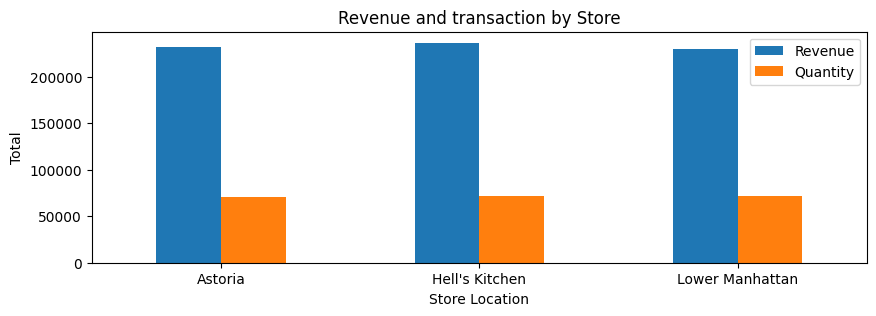

In [292]:
#店舗ごとのRevenue、来店人数の分布を確認する
pivot_table_store = transaction_df.pivot_table(values=['Revenue', 'quantity'], index='store_location', aggfunc='sum')
pivot_table_store.plot(kind='bar', figsize=(10, 3))
import matplotlib.pyplot as plt
plt.title('Revenue and transaction by Store')
plt.xlabel('Store Location')
plt.ylabel('Total')
plt.xticks(rotation=0)
plt.legend(['Revenue', 'Quantity'])
plt.show()


来客の人数単位の違いがないかを3店舗で検討した結果、Lower Manhattanのみで3名以上の来店が多いことが確認された

In [293]:
#quantityが2以上の場合は、2名以上で来店していると考えられる。2名、3名、4名以上で条件を作るため、group_sizeを作る
transaction_df['group_size'] = transaction_df['quantity'].apply(lambda x: '4 or more' if x >= 4 else '3' if x >= 3 else '2' if x >= 2 else '1')
print(transaction_df.groupby('group_size')['quantity'].count())
#来客人数による違いを見るためにquantityの列を複製する
transaction_df['quantity_group'] = transaction_df['quantity']

group_size
1            87159
2            58642
3             3279
4 or more       36
Name: quantity, dtype: int64


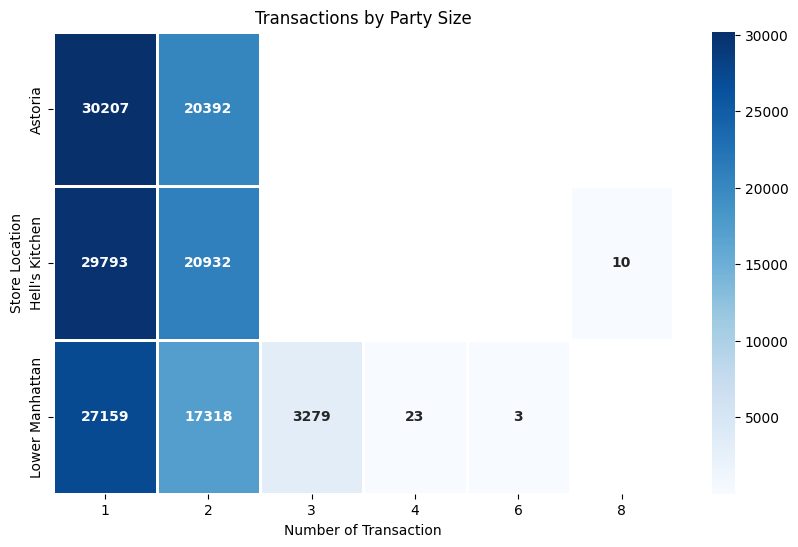

In [309]:
import seaborn as sns
import matplotlib.pyplot as plt
#quantityとstore_locationでクロス集計して、来店人数を比較するヒートマップを作る
customer_df = transaction_df.pivot_table(values='quantity', index='store_location', columns='quantity_group', aggfunc='count')

plt.figure(figsize=(10, 6))
sns.heatmap(customer_df,
    cmap='Blues', #「青」グラデーション
    annot=True,    # マスの中に数字を表示
    fmt='.0f',             # 四捨五入して整数
    linewidths=0.8,        # マス目の間に綺麗な隙間を作る
    linecolor='white',     # 隙間の色は白
    cbar=True,             # 右側に色の濃さの目盛り（カラーバー）
    annot_kws={'size': 10, 'weight': 'bold'} #数字を少し太文字
)
plt.title('Transactions by Party Size')
plt.xlabel('Number of Transaction')
plt.ylabel('Store Location')
plt.show()

次に時間帯による差異を見るため、営業時間である12時間を、朝、昼、夜に3分割して傾向を確認した結果、Lower Manhattanの夕方の来客が少なく、Astoriaでは朝の来客が少ない傾向が確認された。

In [295]:
#Hourを使って、午前、昼間、夕方、夜の時間帯に分けて、時間帯ごとの来店人数の分布を確認する
transaction_df['Hour_group'] = transaction_df['Hour'].apply(lambda x: 'morning' if x < 12 else 'afternoon' if x < 16 else 'evening' )
transaction_df.dtypes
#Hour_groupをカテゴリーとして並び順を固定する
transaction_df['Hour_group'] = pd.Categorical(transaction_df['Hour_group'], categories=['morning', 'afternoon', 'evening'], ordered=True)
#Weekday.1とmonth.1をカテゴリーとして並び順を定義する
transaction_df['Weekday_group'] = pd.Categorical(transaction_df['Weekday.1'], categories=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], ordered=True)
transaction_df['Month_group'] = pd.Categorical(transaction_df['Month.1'], categories=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul'], ordered=True)

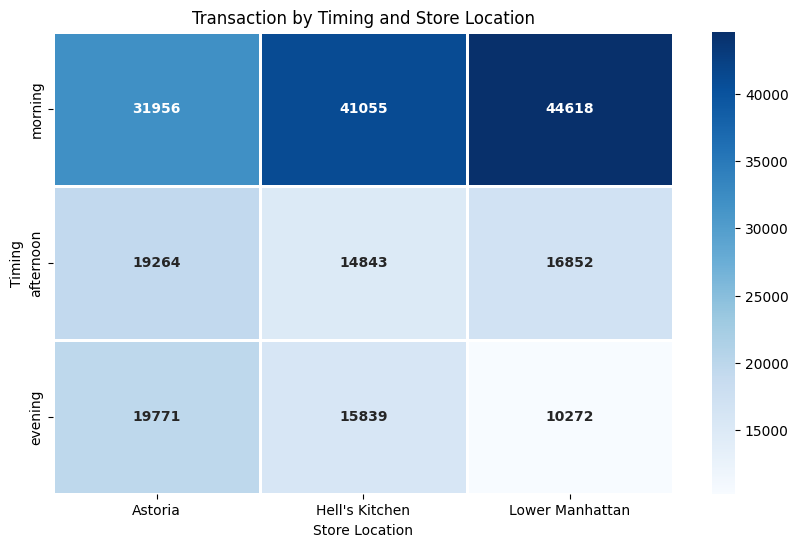

In [343]:
#Hour_groupとstore_locationでクロス集計して、Revenueを比較するヒートマップを作る
customer_Hour_df = transaction_df.pivot_table(values='quantity', index='Hour_group', columns='store_location', aggfunc='sum')
plt.figure(figsize=(10, 6))
sns.heatmap(customer_Hour_df,
    cmap='Blues', #「青」グラデーション
    annot=True,    # マスの中に数字を表示
    fmt='.0f',             # 四捨五入して整数
    linewidths=0.8,        # マス目の間に綺麗な隙間を作る
    linecolor='white',     # 隙間の色は白
    cbar=True,             # 右側に色の濃さの目盛り（カラーバー）
    annot_kws={'size': 10, 'weight': 'bold'} #数字を少し太文字
)
plt.title('Transaction by Timing and Store Location')
plt.xlabel('Store Location')
plt.ylabel('Timing')
plt.show()

ヒートマップの結果が偶然の結果かどうか検証を行った結果、有意差が認められた。

In [353]:
import numpy as np
from scipy import stats

df_chi2 = customer_Hour_df.copy()
print("検定に使用するクロス集計表:")
print(df_chi2)
print("-" * 50)
# chi2: カイ二乗値, p: p値, dof: 自由度, expected: 期待度数
chi2, p, dof, expected = stats.chi2_contingency(df_chi2)
print(f"カイ二乗統計量: {chi2:.2f}")
print(f"p値 (p-value): {p:4f}") 

# 判定結果の出力
alpha = 0.05 # 一般的な有意水準

print("-" * 50)
print("期待度数")
df_expected = pd.DataFrame(expected, index=df_chi2.index, columns=df_chi2.columns)
print(df_expected.round(1))

検定に使用するクロス集計表:
store_location  Astoria  Hell's Kitchen  Lower Manhattan
Hour_group                                              
morning           31956           41055            44618
afternoon         19264           14843            16852
evening           19771           15839            10272
--------------------------------------------------
カイ二乗統計量: 5736.51
p値 (p-value): 0.000000
--------------------------------------------------
期待度数
store_location  Astoria  Hell's Kitchen  Lower Manhattan
Hour_group                                              
morning         38936.0         39345.1          39347.9
afternoon       16867.8         17045.0          17046.2
evening         15187.2         15346.8          15347.9


カイ二乗検定の結果、3店舗の間には有意差が認められたが、Lower Manhattanの夕方と、Astoriaの朝に統計的な差があるかどうかは、判別できないため、残差分析を実施した。

In [354]:
# stats.chi2_contingency の結果から調整残差を算出
data_matrix = df_chi2.values

n= data_matrix.sum()
row_totals = data_matrix.sum(axis=1)
col_totals = data_matrix.sum(axis=0)

# 期待度数の再計算
expected = np.outer(row_totals, col_totals) / n

# 調整残差の計算公式
row_ratios = row_totals / n
col_ratios = col_totals / n
variance = expected * np.outer(1 - row_ratios, 1 - col_ratios)
adjusted_residuals = (data_matrix - expected) / np.sqrt(variance)

df_residuals = pd.DataFrame(
    adjusted_residuals, 
    index=df_chi2.index, 
    columns=df_chi2.columns
)
print("各時間帯×店舗の【調整残差】スコア:")
print(df_residuals.round(2))
print("-" * 60)
print(" +2.0以上なら『有意に多い』、-2.0以下なら『有意に少ない』")

各時間帯×店舗の【調整残差】スコア:
store_location  Astoria  Hell's Kitchen  Lower Manhattan
Hour_group                                              
morning          -64.36           15.72            48.47
afternoon         25.83          -23.68            -2.09
evening           51.29            5.49           -56.65
------------------------------------------------------------
 +2.0以上なら『有意に多い』、-2.0以下なら『有意に少ない』


以上の結果から3店舗の来店人数については、見た目通り差異があることが確認された

次に売上ベースでの検討を行った。店舗と曜日での売上の差異を比較したが、店舗内で曜日によって明らかな増減は確認できなかった。

In [299]:
#Hour_groupとWeekday_groupでクロス集計して、店舗ごとに曜日による売上への影響を確認する
hour_weekday_df = transaction_df.pivot_table(values='Revenue', index=['store_location'], columns='Weekday_group', aggfunc='sum')
hour_weekday_df


Weekday_group,Mon,Tue,Wed,Thu,Fri,Sat,Sun
store_location,,,,,,,
Astoria,33928.29,31816.76,34244.63,34140.37,33472.75,31845.93,32795.18
Hell's Kitchen,33389.51,34846.47,33779.09,33468.06,34743.18,32599.23,33685.63
Lower Manhattan,34359.48,32792.71,32289.82,33159.35,33157.07,32449.32,31849.50


特定の商品が特定の曜日に売れている可能性を考慮し、確認を実施したが、大きな違いは見られなかった。

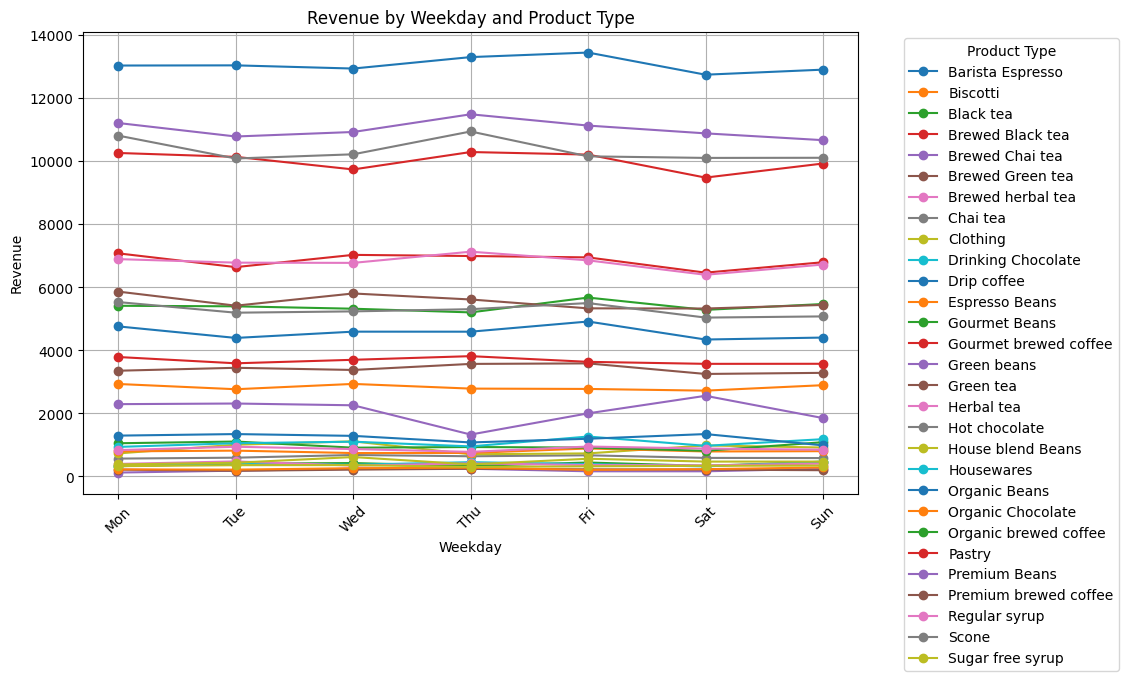

In [300]:
#Weekday_groupを横軸にProduct_Typeごとの売上を折れ線グラフで示し、時期による売上の変化を見る
pivot_table_weekday = transaction_df.pivot_table(values='Revenue', index='Weekday_group', columns='product_type', aggfunc='sum')
pivot_table_weekday.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Revenue by Weekday and Product Type')
plt.xlabel('Weekday')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Product Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()

特定の商品が特定の店舗に売れている可能性を考慮し、確認を実施したが、大きな違いは見られなかった。

In [355]:
#store_location別にproduct_categoryのRevenueを確認し、特定の商品が特定の店舗で売れているか確認する
pivot_table_hour = transaction_df.pivot_table(values='Revenue', index='store_location', columns='product_category', aggfunc='sum')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table_hour,
    cmap='Blues', 
    annot=True,   
    fmt='.0f',    
    linewidths=0.8,     
    linecolor='white',  
    cbar=True,        
    annot_kws={'size': 10, 'weight': 'bold'} 
    
plt.title('Revenue by store location and product category')
plt.xlabel('Weekday')
plt.ylabel('Hour Group')
plt.show()

SyntaxError: '(' was never closed (2371239150.py, line 4)

時系列での変化を見るためにまず3店舗の売上推移を見た結果、いずれの店舗も右肩上がりに売上が伸びていた。

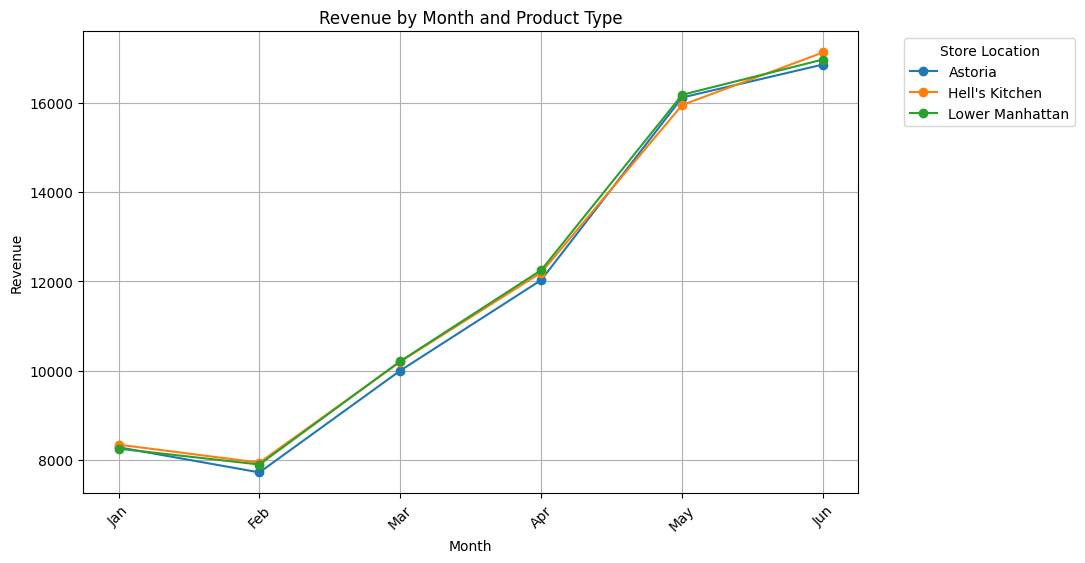

In [302]:
#Month_groupを横軸にstore_location毎のReveueを折れ線グラフで示し、売上の変化を見る
pivot_table_month = transaction_df.pivot_table(values='quantity', index='Month_group', columns='store_location', aggfunc='sum')
pivot_table_month.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Revenue by Month and Product Type')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid()
#legendをグラフの外に配置する
plt.legend(title='Store Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()  

右肩上がりに貢献している商品の確認を実施し、特定の商品が売上を牽引していることが確認された。

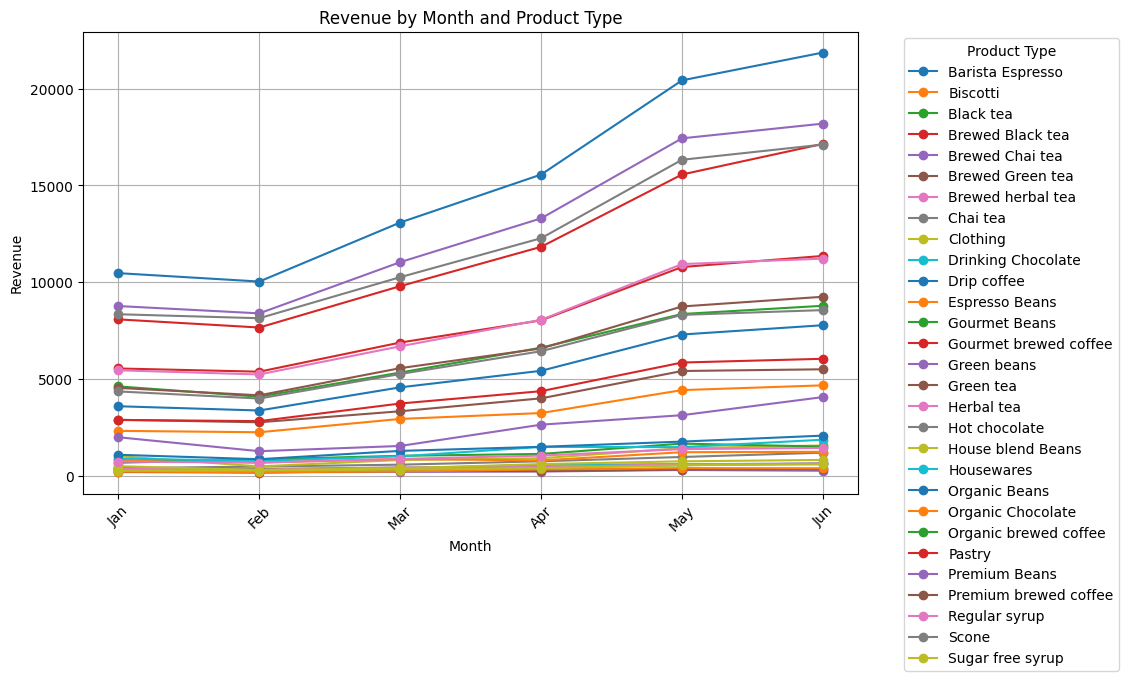

In [356]:
#Month_groupを横軸にProduct_Typeごとの売上を折れ線グラフで示し、時期による売上の変化を見る
pivot_table_month = transaction_df.pivot_table(values='Revenue', index='Month_group', columns='product_type', aggfunc='sum')
pivot_table_month.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Revenue by Month and Product Type')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid()
plt.legend(title='Product Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()  

以上の結果から、一度、売上を目的変数、曜日、時間帯、店舗、月、商品分類名を説明変数に重回帰分析を実施した。

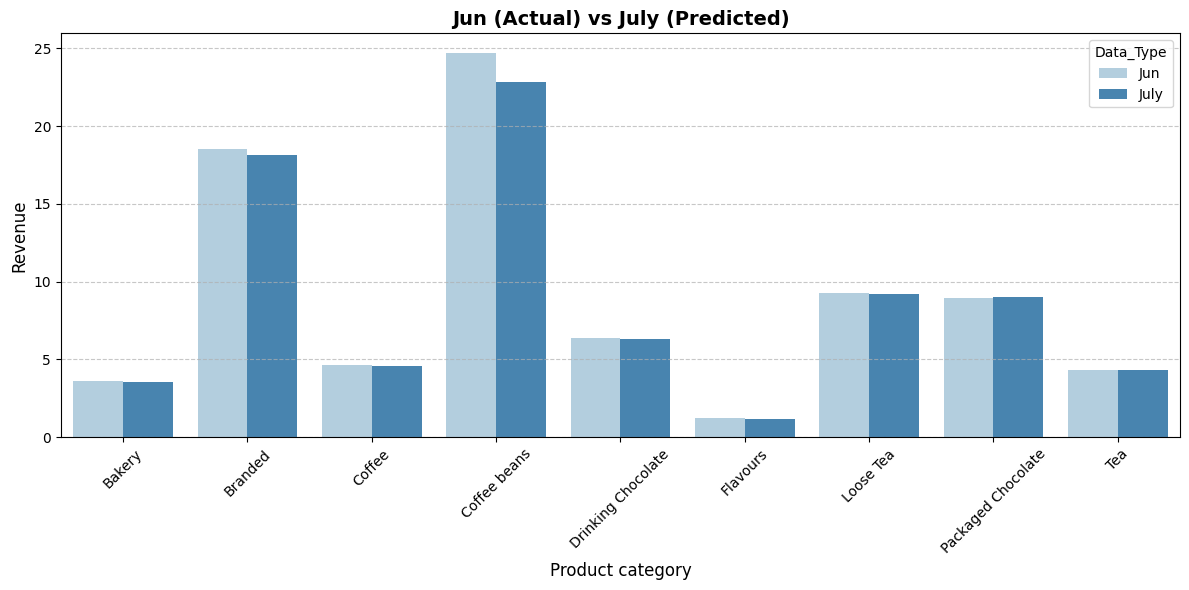

In [357]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

# 前処理：説明変数（X）と目的変数（y）の準備
categorical_features = ["Hour_group", "product_category", "store_location", "Month_group","Weekday_group"]
X = transaction_df[categorical_features]
y = transaction_df["Revenue"]
# カテゴリ変数の列（文字データ）だけをOne-Hotエンコーディング
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_encoded = encoder.fit_transform(X)
# X_finalはOne-Hot変換されたカテゴリ変数だけで構成
X_final = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_features))

# モデルの学習
model = LinearRegression()
model.fit(X_final, y)

# 7月の未来予測データの作成（過学習対策で全期間の平均パターンを抽出）
# 全期間（transaction_df）から時間・商品・店舗の平均パターンを作る
future_base = (
    transaction_df.groupby(["Hour_group", "product_category", "store_location","Weekday_group"])
    .size()
    .reset_index(name="count")
)
# size() を使うことで、「その時間・その商品・その店舗」の標準的な組み合わせ枠を作る
# 予測したい7月の情報を入れた列を作る
future_base["Month_group"] = "Jul"
# 未来データの変換と予測（AIによる売上予測）
# 学習時と同じエンコーダーを使って、未来予測データをOne-Hot変換
future_encoded = encoder.transform(future_base[categorical_features])
future_final = pd.DataFrame(
    future_encoded, columns=encoder.get_feature_names_out(categorical_features)
)
# モデルに予測させる
future_base["predicted_revenue"] = model.predict(future_final)
# 可視化（直近6月の実績平均と、7月の予測値の差異を比較）
# 比較対象として、直近6月のリアルな実績データを抽出
df_6 = transaction_df[transaction_df["Month_group"] == "Jun"]

actual_6 = df_6.groupby(["product_category"])["Revenue"].mean().reset_index().rename(columns={"Revenue": "Jun"})
pred_7 = (
    future_base.groupby(["product_category"])["predicted_revenue"]
    .mean()
    .reset_index()
    .rename(columns={"predicted_revenue": "July"})
)
# 商品タイプを軸にして2つのデータをマージ
comparison_df = pd.merge(actual_6, pred_7, on="product_category")
# グラフ用にデータを整形
comparison_melted = comparison_df.melt(
    id_vars="product_category", var_name="Data_Type", value_name="Revenue"
)

# グラフ描画
plt.figure(figsize=(12, 6))
sns.barplot(
    x="product_category",
    y="Revenue",
    hue="Data_Type",
    data=comparison_melted,
    palette="Blues",
)

plt.title("Jun (Actual) vs July (Predicted)", fontsize=14, fontweight="bold")
plt.xlabel("Product category", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [358]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# 6月のリアルな実績データをテスト用として抽出
df_jun_test = transaction_df[transaction_df["Month_group"] == "Jun"].copy()
# 6月テストデータの「説明変数（X）」と「目的変数（y：実際の売上）」を準備
# （※前処理で作成した X_final のインデックスと合わせます）
X_jun_test = X_final.loc[df_jun_test.index]
y_jun_actual = df_jun_test["Revenue"]
# 6月のデータを使って、モデルに売上を予測させてみる
y_jun_pred = model.predict(X_jun_test)
# 各種評価指標の計算
r2 = r2_score(y_jun_actual, y_jun_pred)
mae = mean_absolute_error(y_jun_actual, y_jun_pred)
rmse = np.sqrt(mean_squared_error(y_jun_actual, y_jun_pred))
# 結果の表示
print("=== 重回帰モデル結果===")
print(f"■ R2スコア（決定係数） : {r2:.4f}")
print(f"■ MAE（平均絶対誤差）  : {mae:.2f} ドル")
print(f"■ RMSE（二乗平均平方根誤差）: {rmse:.2f} ドル")
print("======================")

=== 重回帰モデル結果===
■ R2スコア（決定係数） : 0.2825
■ MAE（平均絶対誤差）  : 1.51 ドル
■ RMSE（二乗平均平方根誤差）: 4.14 ドル


モデルの改善に向けて説明変数の調整を行った。上記は細かすぎるので、product_category=>Hour_groupの順に説明変数から抜いて検討した。以下は、Hour_groupまで抜き、Dailyの売上をベースにして分析した。

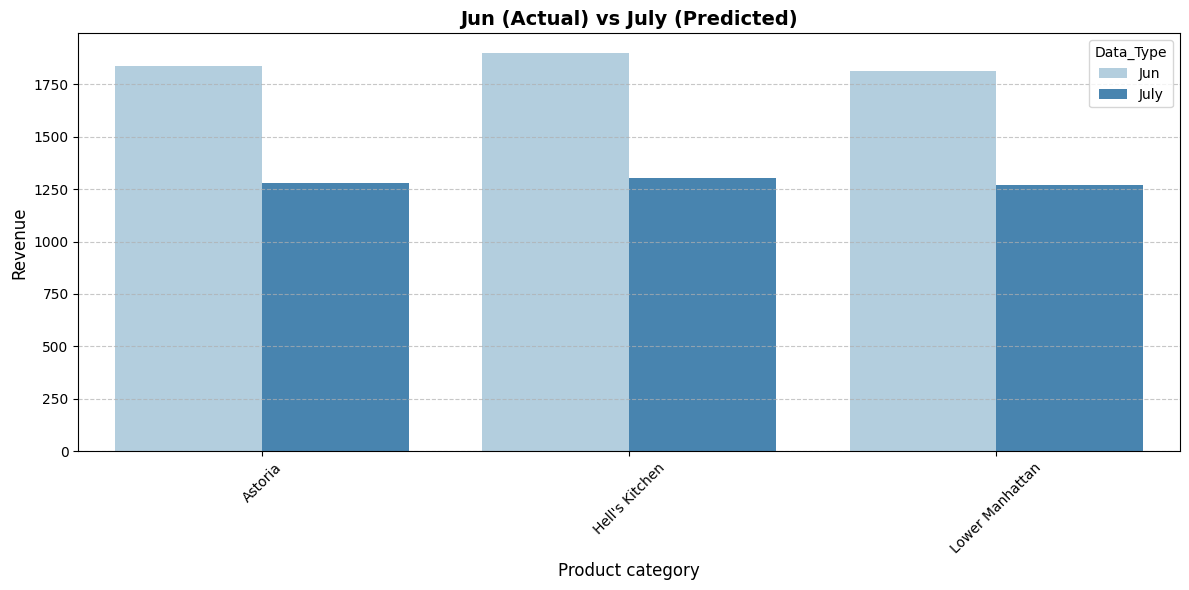

In [359]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

# 前処理：説明変数（X）と目的変数（y）の準備
df_daily = (
    transaction_df.groupby(["transaction_date", "store_location", "Month_group", "Weekday_group"])["Revenue"]
    .sum() 
    .reset_index())

categorical_features = ["store_location", "Month_group","Weekday_group"]
X = df_daily[categorical_features]
y = df_daily["Revenue"]
# カテゴリ変数の列（文字データ）だけをOne-Hotエンコーディング
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_encoded = encoder.fit_transform(X)
# X_finalはOne-Hot変換されたカテゴリ変数だけで構成
X_final = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_features))
# モデルの学習
model = LinearRegression()
model.fit(X_final, y)

# 7月の未来予測データの作成（過学習対策で全期間の平均パターンを抽出）
#全期間（transaction_df）から時間・商品・店舗の平均パターンを作る
future_base = (
    transaction_df.groupby(["store_location","Weekday_group"])
    .size()
    .reset_index(name="count")
)
#  size() を使うことで、「その時間・その商品・その店舗」の標準的な組み合わせ枠を作る
# 予測したい7月の情報を入れた列を作る
future_base["Month_group"] = "Jul"
# 未来データの変換と予測（AIによる売上予測）
# 学習時と同じエンコーダーを使って、未来予測データをOne-Hot変換
future_encoded = encoder.transform(future_base[categorical_features])
future_final = pd.DataFrame(
    future_encoded, columns=encoder.get_feature_names_out(categorical_features)
)
future_base["predicted_revenue"] = model.predict(future_final)
# 可視化（直近6月の実績平均と、7月の予測値の差異を比較）
# 比較対象として、直近6月のリアルな実績データを抽出
df_6 = df_daily[df_daily["Month_group"] == "Jun"]
actual_6 = df_6.groupby(["store_location"])["Revenue"].mean().reset_index().rename(columns={"Revenue": "Jun"})
pred_7 = (
    future_base.groupby(["store_location"])["predicted_revenue"]
    .mean()
    .reset_index()
    .rename(columns={"predicted_revenue": "July"})
)
# 商品タイプを軸にして2つのデータをマージ
comparison_df = pd.merge(actual_6, pred_7, on="store_location")
# グラフ用にデータを整形
comparison_melted = comparison_df.melt(
    id_vars="store_location", var_name="Data_Type", value_name="Revenue"
)

# グラフ描画
plt.figure(figsize=(12, 6))
sns.barplot(
    x="store_location",
    y="Revenue",
    hue="Data_Type",
    data=comparison_melted,
    palette="Blues",
)

plt.title("Jun (Actual) vs July (Predicted)", fontsize=14, fontweight="bold")
plt.xlabel("Product category", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [360]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

df_jun_test = df_daily_clean[df_daily_clean["Month_group"] == "Jun"].copy()

X_jun_test = X_final.loc[df_jun_test.index]
y_jun_actual = df_jun_test["Revenue"]

y_jun_pred = model.predict(X_jun_test)

r2 = r2_score(y_jun_actual, y_jun_pred)
mae = mean_absolute_error(y_jun_actual, y_jun_pred)
rmse = np.sqrt(mean_squared_error(y_jun_actual, y_jun_pred))

# 結果の表示
print("=== 日次合計の銃開始分析 ===")
print(f"■ R2スコア（決定係数） : {r2:.4f}")
print(f"■ MAE（平均絶対誤差）  : {mae:.2f} ドル")
print(f"■ RMSE（二乗平均平方根誤差）: {rmse:.2f} ドル")
print("===========================")

=== 日次合計の銃開始分析 ===
■ R2スコア（決定係数） : -4.7885
■ MAE（平均絶対誤差）  : 581.11 ドル
■ RMSE（二乗平均平方根誤差）: 693.40 ドル


次にラグ特徴を追加してもう一度、重回帰分析を実施した。

複雑なインデックス構造を完全に攻略し、モデルの学習が完了しました！


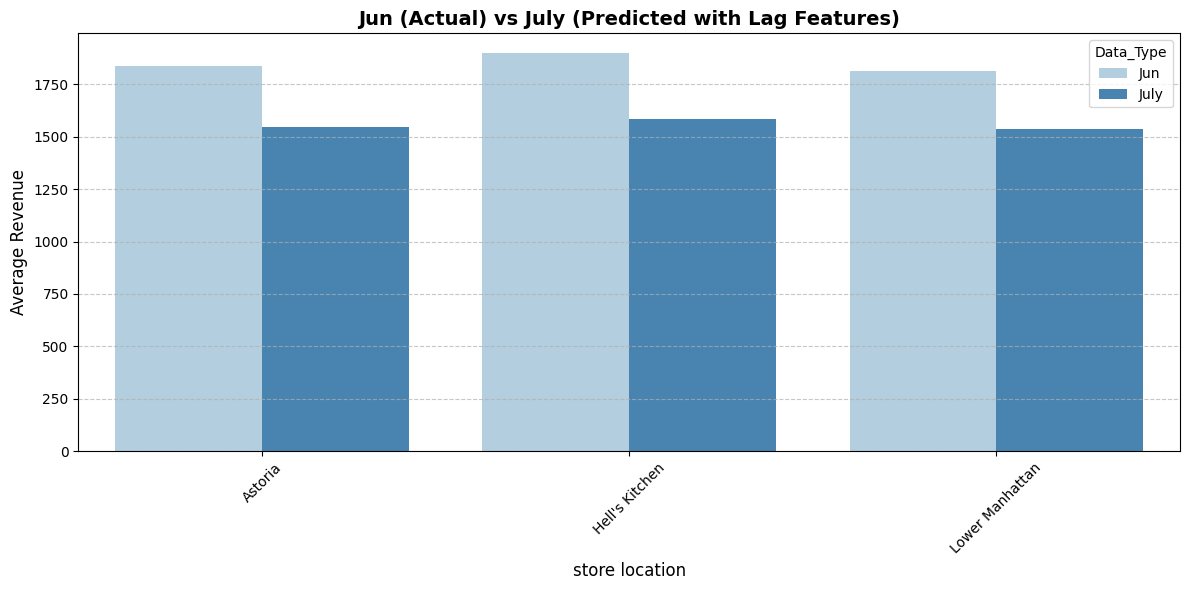

In [361]:
df_daily = (
    transaction_df.groupby(
        [
            "transaction_date",
            "store_location",
            "Weekday_group",
            "Month_group",
        ]
    )["Revenue"]
    .sum()
    .reset_index()
)

df_daily = df_daily.sort_values(
    by=["store_location", "transaction_date"]
).reset_index(drop=True)

group = df_daily.groupby(["store_location"])["Revenue"]

# ① 1日前の売上
df_daily["revenue_lag_1"] = group.shift(1)

# ② 7日前の売上
df_daily["revenue_lag_7"] = group.shift(7)

# transform(lambda x: ...) でマルチインデックス化を防ぐ
df_daily["revenue_roll_mean_7"] = group.transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)
# 過去データがない初期の数日間（NaN）を削除し、インデックスをリセット
df_daily_clean = df_daily.dropna().reset_index(drop=True)

# 前処理（One-Hotエンコーディングと数値の結合）
categorical_features = [
    "store_location",
    "Weekday_group",
    "Month_group",
]
numeric_features = ["revenue_lag_1", "revenue_lag_7", "revenue_roll_mean_7"]

# カテゴリ変数のOne-Hotエンコーディング
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat_encoded = encoder.fit_transform(df_daily_clean[categorical_features])

# エンコーディング後のDFを作成
X_cat_df = pd.DataFrame(
    X_cat_encoded,
    columns=encoder.get_feature_names_out(categorical_features),
    index=df_daily_clean.index,
)
# 数値列（ラグ特徴量）を切り出し
X_num_df = df_daily_clean[numeric_features]
# 横結合
X_final = pd.concat([X_cat_df, X_num_df], axis=1)
y = df_daily_clean["Revenue"]

# モデルの学習
model = LinearRegression()
model.fit(X_final, y)
print("複雑なインデックス構造を完全に攻略し、モデルの学習が完了しました！")

# 7月の未来予測データの作成（ラグ特徴量のダミー生成）
future_base = (
    df_daily_clean.groupby(
        ["store_location", "Weekday_group"]
    )
    .size()
    .reset_index(name="count")
)

# 予測したい月を「7月」に設定
future_base["Month_group"] = "Jul"

# 6月の直近の実績データから、各店舗・カテゴリの「平均的な過去の売上」を計算し、
# それを7月の予測用の特徴量として紐付け
lag_defaults = (
    df_daily_clean[df_daily_clean["Month_group"] == "Jun"]
    .groupby(["store_location"])[
        ["revenue_lag_1", "revenue_lag_7", "revenue_roll_mean_7"]
    ]
    .mean()
    .reset_index()
)

# 組み合わせ枠に、過去の売上トレンドの数値を合流（マージ）
future_base = pd.merge(
    future_base, lag_defaults, on=["store_location"]
)

# 未来データのOne-Hot変換と予測
# カレンダー系のカテゴリ変数をOne-Hot変換
future_encoded = encoder.transform(future_base[categorical_features])
future_cat_df = pd.DataFrame(
    future_encoded,
    columns=encoder.get_feature_names_out(categorical_features),
    index=future_base.index,
)

# 数値系（作成したラグの平均値）を切り出し
future_num_df = future_base[numeric_features]

# カテゴリと数値を横結合して、モデルに渡す最終データ（X）を完成させる
future_final = pd.concat([future_cat_df, future_num_df], axis=1)

# モデルに7月の売上を予測させる
future_base["predicted_revenue"] = model.predict(future_final)

# 可視化（6月の実績と7月の予測の比較）
# 6月のリアルな実績データの平均
df_6 = df_daily_clean[df_daily_clean["Month_group"] == "Jun"]
actual_6 = (
    df_6.groupby(["store_location"])["Revenue"]
    .mean()
    .reset_index()
    .rename(columns={"Revenue": "Jun"})
)

# 7月の予測データの平均
pred_7 = (
    future_base.groupby(["store_location"])["predicted_revenue"]
    .mean()
    .reset_index()
    .rename(columns={"predicted_revenue": "July"})
)

# 結合してマージ
comparison_df = pd.merge(actual_6, pred_7, on="store_location")
comparison_melted = comparison_df.melt(
    id_vars="store_location", var_name="Data_Type", value_name="Revenue"
)

# グラフ描画
plt.figure(figsize=(12, 6))
sns.barplot(
    x="store_location",
    y="Revenue",
    hue="Data_Type",
    data=comparison_melted,
    palette="Blues",
)

plt.title(
    "Jun (Actual) vs July (Predicted with Lag Features)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("store location", fontsize=12)
plt.ylabel("Average Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [362]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

df_jun_test = df_daily_clean[df_daily_clean["Month_group"] == "Jun"].copy()

X_jun_test = X_final.loc[df_jun_test.index]
y_jun_actual = df_jun_test["Revenue"]

y_jun_pred = model.predict(X_jun_test)

r2 = r2_score(y_jun_actual, y_jun_pred)
mae = mean_absolute_error(y_jun_actual, y_jun_pred)
rmse = np.sqrt(mean_squared_error(y_jun_actual, y_jun_pred))

print("=== 日次合計の重回帰分析 ===")
print(f"■ R2スコア（決定係数） : {r2:.4f}")
print(f"■ MAE（平均絶対誤差）  : {mae:.2f} ドル")
print(f"■ RMSE（二乗平均平方根誤差）: {rmse:.2f} ドル")
print("===========================")

=== 日次合計の重回帰分析 ===
■ R2スコア（決定係数） : 0.1844
■ MAE（平均絶対誤差）  : 206.15 ドル
■ RMSE（二乗平均平方根誤差）: 260.28 ドル


ラグ特徴量を追加することでモデルは改善したが、重回帰分析では、時系列の要素を勘定しにくい側面があるため、時系列分析を行った。

10:30:08 - cmdstanpy - INFO - Chain [1] start processing
10:30:08 - cmdstanpy - INFO - Chain [1] done processing
10:30:09 - cmdstanpy - INFO - Chain [1] start processing
10:30:09 - cmdstanpy - INFO - Chain [1] done processing
10:30:10 - cmdstanpy - INFO - Chain [1] start processing
10:30:10 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\user\AppData\Local\Temp\ipykernel_5568\2244144525.py:62: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5568\2244144525.py:62: UserWarning: Glyph 12371 (\N{HIRAGANA LETTER KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5568\2244144525.py:62: UserWarning: Glyph 12363 (\N{HIRAGANA LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5568\2244144525.py:62: UserWarning: Glyph 12425 (\N{HIRAGANA LETTER RA}) missing from font(s) Dej

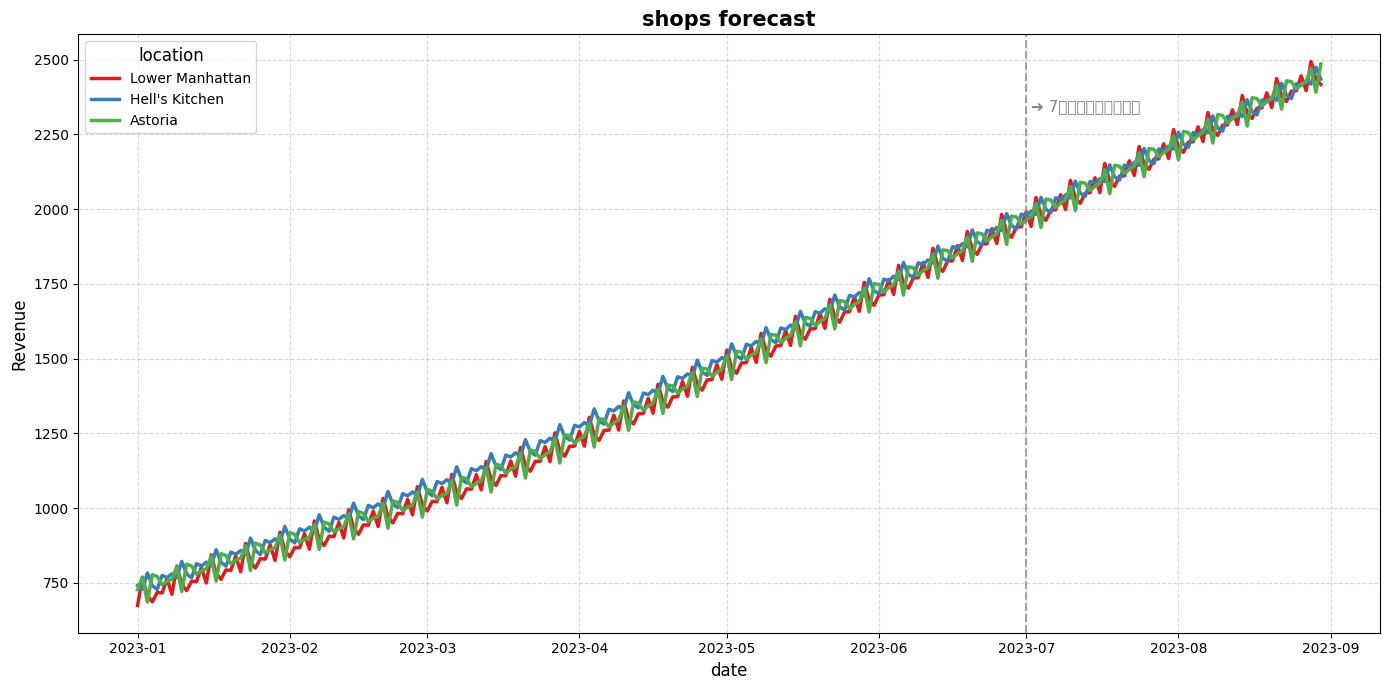

In [363]:
# 重ね合わせのグラフ用に、空のデータフレームを用意
all_store_forecasts = []

# データにあるユニークな店舗名（3件）をループで1ずつ処理
unique_stores = transaction_df['store_location'].unique()

for store in unique_stores:
    # 対象の店舗のデータだけを抽出
    store_df = transaction_df[transaction_df['store_location'] == store]
    
    # 日付ごとに売上を合計
    daily_revenue = store_df.groupby('transaction_date')['Revenue'].sum().reset_index()
    df_prophet = daily_revenue.rename(columns={'transaction_date': 'ds', 'Revenue': 'y'})
    df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
    
    # Prophetで学習（半年データなので yearly_seasonality は False）
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    model.fit(df_prophet)
    
    # 7月・8月（61日間）の予測枠を作成して予測
    future = model.make_future_dataframe(periods=61)
    forecast = model.predict(future)
    
    # グラフ用に「店舗名」の列を足して、結果をリストに保存
    forecast['store_location'] = store
    # 過去実績の黒点と混ぜるため、ds（日付）と yhat（予測値）をキープ
    all_store_forecasts.append(forecast[['ds', 'yhat', 'store_location']])

# 3店舗分の予測データを1つに合体
df_plot = pd.concat(all_store_forecasts, ignore_index=True)

# 1つのグラフに重ね合わせて可視化

plt.figure(figsize=(14, 7))

# Seabornの lineplot を使って、店舗ごとに色（hue）を分けて線を引く
# yhat が Prophetの弾き出した売上（予測＋過去のトレンド線）です
sns.lineplot(
    data=df_plot, 
    x='ds', 
    y='yhat', 
    hue='store_location', 
    linewidth=2.5,
    palette='Set1' # 見やすいはっきりした配色
)

# 7月（未来予測）のエリアがどこからか分かるように、点線の境界線を引く
plt.axvline(x=pd.to_datetime('2023-07-01'), color='gray', linestyle='--', alpha=0.7)
plt.text(pd.to_datetime('2023-07-02'), plt.ylim()[1]*0.9, '➔ 7月ここから未来予測', color='gray', fontsize=11)

# グラフの装飾
plt.title('shops forecast',  fontsize=15, fontweight='bold')
plt.xlabel('date', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.legend(title='location', title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [364]:
from prophet import Prophet  
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 新しく作った日次合計データ（df_daily_clean）から、まずは1店舗（Astoria店）を抽出
df_store = df_daily_clean[df_daily_clean["store_location"] == "Astoria"].copy()

# Prophetが要求する「ds（日付）」と「y（売上）」に列名をリネーム
df_prophet = df_store.rename(columns={"transaction_date": "ds", "Revenue": "y"})

# 5月末までを「学習データ（過去）」、6月を「テストデータ（検証用の未来）」に分割
train_df = df_prophet[df_prophet["Month_group"] != "Jun"]
test_df = df_prophet[df_prophet["Month_group"] == "Jun"]

# データの期間に合わせて季節性を設定
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(train_df)

# 3. 6月の期間を予測させる
# 6月のテストデータの日付（ds）だけを渡して、予測値を計算
forecast = prophet_model.predict(test_df[["ds"]])

# 4. 6月の「実際の売上」と「Prophetの予測値」で答え合わせ
y_actual = test_df["y"].values
y_pred = forecast["yhat"].values  # yhatがProphetの予測値です

# 精度指標の計算
r2_prophet = r2_score(y_actual, y_pred)
mae_prophet = mean_absolute_error(y_actual, y_pred)
rmse_prophet = np.sqrt(mean_squared_error(y_actual, y_pred))

print("===Prophet時系列モデル ===")
print(f"■ R2スコア（決定係数） : {r2_prophet:.4f}")
print(f"■ MAE（平均絶対誤差）  : {mae_prophet:.2f} ドル")
print(f"■ RMSE（二乗平均平方根誤差）: {rmse_prophet:.2f} ドル")
print("==========================")

10:31:25 - cmdstanpy - INFO - Chain [1] start processing
10:31:25 - cmdstanpy - INFO - Chain [1] done processing


===Prophet時系列モデル ===
■ R2スコア（決定係数） : -3.9831
■ MAE（平均絶対誤差）  : 513.84 ドル
■ RMSE（二乗平均平方根誤差）: 624.42 ドル


3店舗でほぼ同様の傾向が見られた。次にデイリーの要素を加味して追加で分析した。

10:33:51 - cmdstanpy - INFO - Chain [1] start processing


🛠️ Lower Manhattan 店の暴走対策モデルを学習中...


10:33:51 - cmdstanpy - INFO - Chain [1] done processing
10:33:52 - cmdstanpy - INFO - Chain [1] start processing


🛠️ Hell's Kitchen 店の暴走対策モデルを学習中...


10:33:52 - cmdstanpy - INFO - Chain [1] done processing
10:33:53 - cmdstanpy - INFO - Chain [1] start processing


🛠️ Astoria 店の暴走対策モデルを学習中...


10:33:53 - cmdstanpy - INFO - Chain [1] done processing


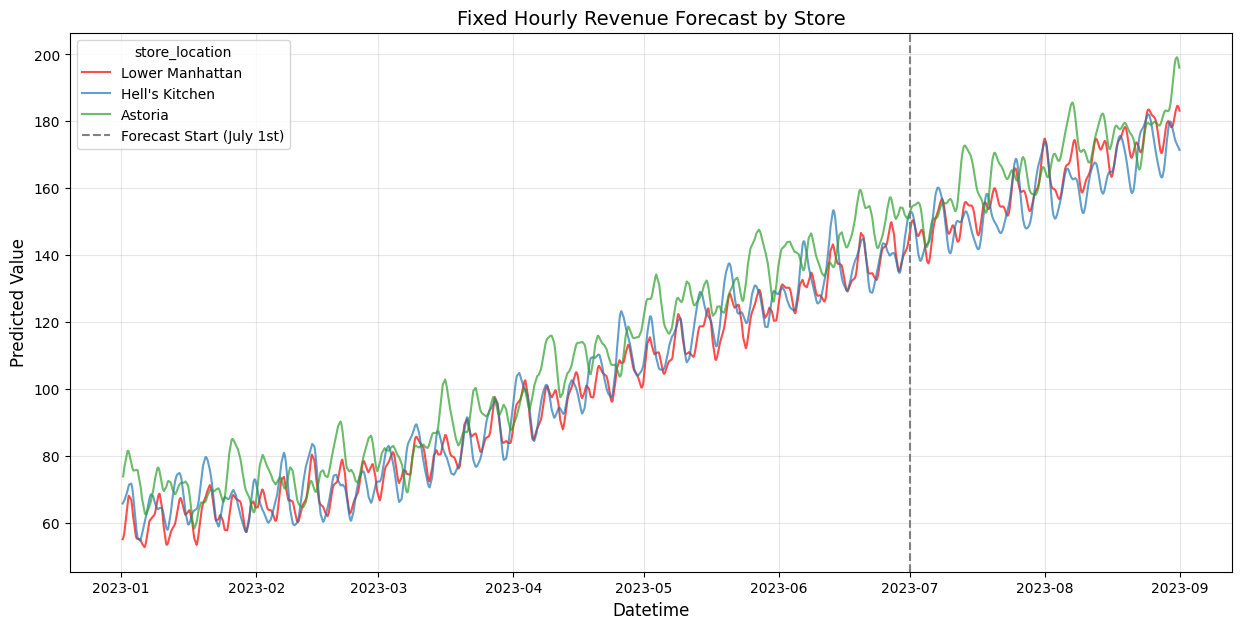

In [365]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
store_df = transaction_df.groupby(['store_location','ds'])['Revenue'].sum().reset_index()
# 予測結果を格納する辞書
forecasts_fixed = {}
stores = ["Lower Manhattan", "Hell's Kitchen", "Astoria"]

for store in stores:
    print(f"🛠️ {store} 店の暴走対策モデルを学習中...")

    # 該当店舗のデータを抽出
    df_store = store_df[
        store_df["store_location"] == store
    ].copy()

    # 自動で売上列を検知して 'y' にリネーム
    value_col = [
        col for col in df_store.columns if col not in ["store_location", "ds"]
    ][0]
    df_prophet = df_store.rename(columns={"ds": "ds", value_col: "y"})[
        ["ds", "y"]
    ]

    # 売上が0のレコードや、深夜・早朝（例: 0時〜5時）のデータを除外する
    # 営業している時間帯（例: 8時〜20時）のデータだけを厳選して学習させます
    df_prophet["hour"] = df_prophet["ds"].dt.hour
    df_prophet = df_prophet[
        (df_prophet["hour"] >= 8) & (df_prophet["hour"] <= 20)
    ]
    df_prophet = df_prophet[df_prophet["y"] > 0]  # 売上がちゃんとある時間だけ

    # モデルの定義（チューニング）
    # データが半年分しかないので、1日の波（daily）の強さを少しマイルドに
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False,  # 一旦自動のdailyをオフにして、下の行で細かく制御
    )
    # 1日の時間帯の波を、マイルドな設定（fourier_order=3〜4程度）で追加
    model.add_seasonality(
        name="hourly", period=24, fourier_order=4, prior_scale=0.1
    )
    model.fit(df_prophet[["ds", "y"]])

    # 3. 未来（7月・8月の2ヶ月間）の予測枠を作成
    future = model.make_future_dataframe(periods=24 * 62, freq="h")

    # 4. 予測の実行
    forecast = model.predict(future)
    forecasts_fixed[store] = forecast

# グラフの描画（営業時間を絞って、綺麗に重ね合わせる）

plt.figure(figsize=(15, 7))
colors = {
    "Lower Manhattan": "red",
    "Hell's Kitchen": "tab:blue",
    "Astoria": "tab:green",
}

for store in stores:
    fcst = forecasts_fixed[store].copy()

    # 営業している時間帯（朝6時〜夜23時）だけを抽出してプロット
    fcst["hour"] = fcst["ds"].dt.hour
    fcst = fcst[(fcst["hour"] >= 6) & (fcst["hour"] <= 23)]

    # グラフにプロット
    plt.plot(
        fcst["ds"], fcst["yhat"], label=store, color=colors[store], alpha=0.7
    )

plt.axvline(
    x=pd.to_datetime("2023-07-01"),
    color="gray",
    linestyle="--",
    label="Forecast Start (July 1st)",
)

plt.title("Fixed Hourly Revenue Forecast by Store", fontsize=14)
plt.xlabel("Datetime", fontsize=12)
plt.ylabel("Predicted Value", fontsize=12)
plt.legend(title="store_location")
plt.grid(True, alpha=0.3)
plt.show()

In [366]:
from prophet import Prophet  # 👈 fbなしの新しい記述に修正
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# データの準備（店舗を絞って検証：例としてAstoria店）
# 新しく作った日次合計データ（df_daily_clean）から、まずは1店舗（Astoria店）を抽出
df_store = df_daily_clean[df_daily_clean["store_location"] == "Astoria"].copy()

# Prophetが要求する「ds（日付）」と「y（売上）」に列名をリネーム
df_prophet = df_store.rename(columns={"transaction_date": "ds", "Revenue": "y"})

# 5月末までを「学習データ（過去）」、6月を「テストデータ（検証用の未来）」に分割
train_df = df_prophet[df_prophet["Month_group"] != "Jun"]
test_df = df_prophet[df_prophet["Month_group"] == "Jun"]

# 2. 5月末までのデータでProphetを学習（6月の未来を知らない状態）
# データの期間に合わせて季節性を設定
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(train_df)

# 3. 6月の期間を予測させる
# 6月のテストデータの日付（ds）だけを渡して、予測値を計算
forecast = prophet_model.predict(test_df[["ds"]])

# 6月の「実際の売上」と「Prophetの予測値」で答え合わせ

y_actual = test_df["y"].values
y_pred = forecast["yhat"].values  # yhatがProphetの予測値です

# 精度指標の計算
r2_prophet = r2_score(y_actual, y_pred)
mae_prophet = mean_absolute_error(y_actual, y_pred)
rmse_prophet = np.sqrt(mean_squared_error(y_actual, y_pred))

print("=== Prophet時系列モデル ===")
print(f"■ R2スコア（決定係数） : {r2_prophet:.4f}")
print(f"■ MAE（平均絶対誤差）  : {mae_prophet:.2f} ドル")
print(f"■ RMSE（二乗平均平方根誤差）: {rmse_prophet:.2f} ドル")
print("==========================")

10:35:20 - cmdstanpy - INFO - Chain [1] start processing
10:35:20 - cmdstanpy - INFO - Chain [1] done processing


=== Prophet時系列モデル ===
■ R2スコア（決定係数） : -3.9831
■ MAE（平均絶対誤差）  : 513.84 ドル
■ RMSE（二乗平均平方根誤差）: 624.42 ドル


以上の結果から重回帰分析の結果を重視し、7月は、売上が頭打ちになると予測する